In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/home/diogo/miniforge3/envs/core_neuron/lib/python')
from neuron import h

from netpyne import sim, specs
import seaborn as sns
import pickle as pkl
import pandas as pd
from scipy import stats as st
import h5py
import os

In [2]:
def _neuron_distance_setup(hobj):
    hobj.push()
    h.distance(0, 0.0)
    h.pop_section()


def _neuron_distance(hobj, x):
    hobj.push()
    d = h.distance(x)
    h.pop_section()
    return d


def _get_longest_branch(hobjs):
    max_L = 0.0
    for hobj in hobjs:
        sref = h.SectionRef(sec=hobj)
        if sref.nchild() == 0:
            d = _neuron_distance(hobj, 1)
            if d > max_L:
                max_L = d
    if max_L == 0.0 and hobjs:
        max_L = _neuron_distance(hobjs[0], 1)
    return max_L


def _locate_sites(hobjs, site):
    hits = []
    for hobj in hobjs:
        d0 = _neuron_distance(hobj, 0)
        d1 = _neuron_distance(hobj, 1)
        if d0 > d1:
            d0, d1 = d1, d0
        if d1 <= d0:
            continue
        if d0 <= site <= d1:
            x = (site - d0) / (d1 - d0)
            x = max(0.01, min(0.99, x))
            hits.append((hobj, x))
    return hits


def insert_ou_noise(sim_obj, cfg_obj, sing_cell_param):
    """Insert CoreNEURON 9.0.1-compatible OU conductance noise."""
    n_total = 0
    type_basal = {}
    type_apical = {}
    type_n_cells = {}

    global_seed = int(cfg_obj.GLOBALSEED) & _UINT32_MASK

    for cell in sim_obj.net.cells:
        cell_type = cell.tags.get("cellType", "")
        gou = sing_cell_param[cell_type]["GOU"]
        gid_seed = int(cell.gid) & _UINT32_MASK

        idx = 0
        n_basal = 0
        n_apical = 0

        def _place_ou(hobj, x_pos, relpos_for_g, site_id):
            g_val = gou * np.exp(relpos_for_g)
            ou = h.Gfluct2(x_pos, sec=hobj)

            ou.E_e = 0.0
            ou.E_i = -80.0
            ou.g_e0 = g_val
            ou.g_i0 = 0.0
            ou.std_e = g_val
            ou.std_i = 0.0
            ou.tau_e = 65.0
            ou.tau_i = 20.0

            # In NEURON 9.0.1, set RANDOM stream properties through the
            # NMODLRandom wrapper instead of random_setids() in the MOD file.
            stream_id3 = (_OU_STREAM_TAG + int(site_id)) & _UINT32_MASK
            ou.rng.set_ids(global_seed, gid_seed, stream_id3)
            ou.rng.set_seq(0)

            _OU_REFS.append(ou)

        dend_secs = [name for name in cell.secs if name.startswith("dend")]
        if dend_secs:
            dend_hobjs = [cell.secs[name]["hObj"] for name in dend_secs]
            _neuron_distance_setup(dend_hobjs[0])
            max_L = _get_longest_branch(dend_hobjs)

            for basal_index, (hobj, x) in enumerate(
                _locate_sites(dend_hobjs, 0.5 * max_L)
            ):
                if cell.gid >= 0:
                    _place_ou(
                        hobj,
                        x,
                        relpos_for_g=0.5,
                        site_id=5 + basal_index,
                    )
                idx += 1
                n_basal += 1

        if "PYR" in cell_type:
            apic_secs = [name for name in cell.secs if name.startswith("apic")]
            if apic_secs:
                apic_hobjs = [cell.secs[name]["hObj"] for name in apic_secs]
                _neuron_distance_setup(apic_hobjs[0])
                max_L_apic = _get_longest_branch(apic_hobjs)

                for apical_index, relpos in enumerate((0.1, 0.3, 0.5, 0.7, 0.9)):
                    hits = _locate_sites(apic_hobjs, relpos * max_L_apic)
                    if not hits:
                        hits = [(apic_hobjs[0], min(relpos, 0.9))]

                    best_hobj, best_x = max(
                        hits,
                        key=lambda item: item[0](item[1]).diam,
                    )
                    if cell.gid >= 0:
                        _place_ou(
                            best_hobj,
                            best_x,
                            relpos_for_g=relpos,
                            site_id=apical_index,
                        )
                    idx += 1
                    n_apical += 1

        n_total += idx
        type_basal[cell_type] = type_basal.get(cell_type, 0) + n_basal
        type_apical[cell_type] = type_apical.get(cell_type, 0) + n_apical
        type_n_cells[cell_type] = type_n_cells.get(cell_type, 0) + 1

    for cell_type in sorted(type_basal):
        n_cells = type_n_cells[cell_type]
        basal_per_cell = type_basal[cell_type] // n_cells
        apical_per_cell = type_apical.get(cell_type, 0) // n_cells
        g_basal_ps = sing_cell_param[cell_type]["GOU"] * np.exp(0.5) * 1e6
        # Optional diagnostics:
        # print(
        #     f"[OU] {cell_type}: {basal_per_cell} basal/cell, "
        #     f"{apical_per_cell} apical/cell, "
        #     f"g_e0_basal={g_basal_ps:.1f} pS"
        # )

    return n_total


# ---------------------------------------------------------------------------
# 3.  Helper: insert tonic GABA inhibition per cell
# ---------------------------------------------------------------------------
def insert_tonic_gaba(sim_obj, cfg_obj, sing_cell_param):
    """Insert tonic GABA (tonic.mod) into soma/basal of all cells,
    and into apical of PYR cells."""
    for cell in sim_obj.net.cells:
        if cell.gid >= 0: # compare with LFPy
            cell_type = cell.tags.get('cellType', '')
            p = sing_cell_param[cell_type]

            if cfg_obj.DRUG:
                g_soma = p['drug_tonic']
                g_apic = p['drug_apic_tonic']
            else:
                g_soma = p['norm_tonic']
                g_apic = p['apic_tonic']

            for sname in [s for s in cell.secs if s.startswith('soma')]:
                sec = cell.secs[sname]['hObj']
                sec.insert('tonic')
                for seg in sec:
                    seg.tonic.g      = g_soma
                    seg.tonic.e_gaba = -75.0

            for sname in [s for s in cell.secs if s.startswith('dend')]:
                sec = cell.secs[sname]['hObj']
                sec.insert('tonic')
                for seg in sec:
                    seg.tonic.g      = g_soma
                    seg.tonic.e_gaba = -75.0

            if 'PYR' in cell_type:
                for sname in [s for s in cell.secs if s.startswith('apic')]:
                    sec = cell.secs[sname]['hObj']
                    sec.insert('tonic')
                    for seg in sec:
                        seg.tonic.g      = g_apic
                        seg.tonic.e_gaba = -75.0

    # print(f'[init] Inserted tonic GABA into {len(sim_obj.net.cells)} cells.')



def load_coreneuron_lfp(filename):

    with h5py.File(filename, "r") as f:

        group = f["report/All"]

        data = group["data"][:]
        element_ids = group["mapping/element_ids"][:]
        node_ids = group["mapping/node_ids"][:]
        index_pointers = group["mapping/index_pointers"][:]
        time_info = group["mapping/time"][:]

    n_cells = len(node_ids)

    n_elements = data.shape[1]

    n_electrodes = n_elements // n_cells

    if n_cells * n_electrodes != n_elements:
        raise ValueError(
            "LFP mapping is not regular: "
            f"{n_elements} elements for {n_cells} cells"
        )

    # time x cell x electrode
    per_cell_lfp = data.reshape(
        data.shape[0],
        n_cells,
        n_electrodes,
    )

    # Sum contribution of every cell.
    #
    # Result:
    # time x electrode
    network_lfp = per_cell_lfp.sum(axis=1)

    return network_lfp, time_info

import pickle


def save_realized_connections(sim_obj, cfg_obj, COMM, RANK):

    # ----------------------------------------------------------
    # Build a normal Python gid -> population lookup
    # ----------------------------------------------------------

    local_gid_to_pop = {
        int(cell.gid): cell.tags['pop']
        for cell in sim_obj.net.cells
    }

    # Need all GIDs because presynaptic cell may live on another MPI rank
    all_gid_to_pop_parts = COMM.allgather(
        local_gid_to_pop
    )

    gid_to_pop = {}

    for part in all_gid_to_pop_parts:
        gid_to_pop.update(part)

    # ----------------------------------------------------------
    # Extract realized connections
    # ----------------------------------------------------------

    local_connections = []

    for cell in sim_obj.net.cells:

        post_gid = int(cell.gid)
        post_pop = cell.tags['pop']

        for conn in cell.conns:

            pre_gid = conn.get('preGid', None)

            if pre_gid is None:
                continue

            # Ignore non-cell sources
            if not isinstance(
                pre_gid,
                (int, np.integer)
            ):
                continue

            pre_gid = int(pre_gid)

            if pre_gid < 0:
                continue

            # Population from actual instantiated network
            pre_pop = gid_to_pop[pre_gid]

            local_connections.append({
                'preGid': pre_gid,
                'postGid': post_gid,

                'prePop': pre_pop,
                'postPop': post_pop,

                'synMech': conn.get('synMech', None),

                'sec': conn.get('sec', None),
                'loc': float(conn.get('loc', 0.5)),

                'weight': float(conn.get('weight', 1.0)),
                'delay': float(conn.get('delay', 0.0)),
            })

    # ----------------------------------------------------------
    # Gather all MPI ranks
    # ----------------------------------------------------------

    gathered = COMM.gather(
        local_connections,
        root=0
    )

    if RANK == 0:

        all_connections = []

        for rank_connections in gathered:
            all_connections.extend(
                rank_connections
            )

        all_connections = sorted(
            all_connections,
            key=lambda x: (
                x['postGid'],
                x['preGid'],
                str(x['sec']),
                x['loc']
            )
        )

        with open(
            cfg_obj.validationConnFile,
            'wb'
        ) as f:

            pickle.dump(
                all_connections,
                f
            )

        print(
            f'[validation] Saved '
            f'{len(all_connections)} realized connections to '
            f'{cfg_obj.validationConnFile}'
        )

    COMM.Barrier()

# **CONFIGURATION**

In [ ]:
# =============================================================================
# cfg.py  —  SimConfig for L23Net NetPyNE Replica (Yao et al. 2022)
# =============================================================================
import sys
import pandas as pd
from netpyne import specs

cfg = specs.SimConfig()
cfg.coreneuron = True
cfg.gpu = True
# ---------------------------------------------------------------------------
# Identity / I/O
# ---------------------------------------------------------------------------
cfg.simLabel = 'v1_jupyter'       #   + str(cfg.cynradNumber)
cfg.saveFolder = '../data/'+cfg.simLabel
cfg.savePickle  = True
cfg.saveJson    = False   # disabled for speed — spikes saved as .npy per seed

cfg.saveDataInclude = ['simData' , 'simConfig', 'netParams']
cfg.backupCfgFile = None 		##  
cfg.gatherOnlySimData = False	##  
cfg.saveCellSecs = True			##  
cfg.saveCellConns = True		##  

cfg.verbose = False
cfg.hParams = {'celsius': 34, 'v_init': -80}  
cfg.verbose = False
cfg.createNEURONObj = True
cfg.createPyStruct = True
cfg.cvode_active = False
cfg.cvode_atol = 1e-6
cfg.cache_efficient = True
cfg.printRunTime = 0.5

cfg.includeParamsLabel = False
cfg.printPopAvgRates = True
cfg.checkErrors = False

cfg.saveValidationConns = False
cfg.loadValidationConns = True

cfg.validationConnFile = 'Connections_rules.pkl'

# ---------------------------------------------------------------------------
# Simulation timing
# ---------------------------------------------------------------------------
cfg.duration = 2000.0    # ms
cfg.dt       = 0.025     # ms  (40 kHz)

# ---------------------------------------------------------------------------
# Random seeds
# ---------------------------------------------------------------------------
cfg.seeds = {'conn':  54321, 'stim':  54321, 'loc':   54321, 'cell':  54321}
cfg.GLOBALSEED = 1234
cfg.DRUG = False

# ---------------------------------------------------------------------------
# LFP recording electrode (only used when cfg.rec_LFP = True)
# ---------------------------------------------------------------------------
cfg.rec_LFP = False
if cfg.rec_LFP == True:
    cfg.recordLFPStep = 0.025 # ms
    cfg.recordLFP = [[0.0, 0.0, 5.0]]

# ---------------------------------------------------------------------------
# Recording — one soma trace per population
# GID layout (full run): PYR 0-799, SST 800-849, PV 850-919, VIP 920-999
# ---------------------------------------------------------------------------


circuit_params = pd.read_excel('Circuit_param.xls', sheet_name = None, index_col = 0)
N_HL23PYR = int(circuit_params['SING_CELL_PARAM'].at['cell_num','HL23PYR'])
N_HL23SST = int(circuit_params['SING_CELL_PARAM'].at['cell_num','HL23SST'])
N_HL23PV = int(circuit_params['SING_CELL_PARAM'].at['cell_num','HL23PV'])
N_HL23VIP = int(circuit_params['SING_CELL_PARAM'].at['cell_num','HL23VIP'])

N_cells = N_HL23PYR + N_HL23SST + N_HL23PV + N_HL23VIP

cell_indices_to_plot = [0, 1, 
                        N_HL23PYR, N_HL23PYR + 1, 
                        N_HL23PYR + N_HL23SST, N_HL23PYR + N_HL23SST + 1, 
                        N_HL23PYR + N_HL23SST + N_HL23PV, N_HL23PYR + N_HL23SST + N_HL23PV + 1]

cfg.recordCells  = cell_indices_to_plot
cfg.recordTraces = {'V_soma': {'sec': 'soma_0', 'loc': 0.5, 'var': 'v'}}

cfg.cellNumber = {}
cfg.cellNumber['HL23PYR'] = N_HL23PYR
cfg.cellNumber['HL23SST'] = N_HL23SST
cfg.cellNumber['HL23PV'] = N_HL23PV
cfg.cellNumber['HL23VIP'] = N_HL23VIP

cfg.cellNumber0 = {}
cfg.cellNumber0['HL23PYR'] = 0
cfg.cellNumber0['HL23SST'] = N_HL23PYR
cfg.cellNumber0['HL23PV'] = N_HL23PYR + N_HL23SST
cfg.cellNumber0['HL23VIP'] = N_HL23PYR + N_HL23SST + N_HL23PV


cfg.cellTypeByIndex = {}

for i in range(N_HL23PYR):
    cfg.cellTypeByIndex[i] = 'HL23PYR'

for i in range(N_HL23PYR, N_HL23PYR + N_HL23SST):
    cfg.cellTypeByIndex[i] = 'HL23SST'

for i in range(N_HL23PYR + N_HL23SST,
               N_HL23PYR + N_HL23SST + N_HL23PV):
    cfg.cellTypeByIndex[i] = 'HL23PV'

for i in range(N_HL23PYR + N_HL23SST + N_HL23PV, N_cells):
    cfg.cellTypeByIndex[i] = 'HL23VIP'


# LFPy conn distribution comparation
cfg.gExc = 0.945 # The factor ~0.945 compensates for the main conn difference
cfg.ROTATE_Y = True
cfg.Change_axon_names = True

#------------------------------------------------------------------------------
# Analysis and plotting 
# ------------------------------------------------------------------------------

Ipops = ['HL23SST', 'HL23PV', 'HL23VIP']
Epops = ['HL23PYR']

cfg.allpops = Epops + Ipops

cfg.recordStep = cfg.dt    # record every time step

cfg.analysis['plotRaster'] = {'include':  cfg.allpops, 'saveFig': True, 'showFig': False,'orderInverse': True, 'timeRange': [0,cfg.duration], 'figSize': (12,6), 'fontSize':4, 'markerSize':4, 'marker': 'o', 'dpi': 300} 
cfg.analysis['plot2Dnet']   = {'include':  cfg.allpops, 'saveFig': True, 'showConns': False, 'figSize': (15,15), 'view': 'xy', 'fontSize':16}   # Plot 2D cells xy
cfg.analysis['plot3Dnet']   = {'include':  cfg.allpops, 'saveFig': True, 'showConns': False, 'figSize': (15,15), 'view': 'xy', 'fontSize':16}   # Plot 2D cells xy
cfg.analysis['plotTraces'] = {'include': cfg.recordCells, 'oneFigPer': 'trace', 'axis': False, 'overlay': False, 'timeRange': [1000,cfg.duration], 'saveFig': True, 'subtitles': None, 'legend': None, 'showFig': False, 'figSize':(18,18)}
cfg.analysis['plotConn'] = {'includePre': cfg.allpops, 'includePost': cfg.allpops, 'feature': 'numConns', 'groupBy': 'pop', 'figSize': (24,24), 
                            'saveFig': True, 'orderBy': 'gid', 'graphType': 'matrix', 'saveData':'v1_batch1_matrix_numConn.json', 'fontSize': 18}


#------------------------------------------------------------------------------
# General network parameters
#------------------------------------------------------------------------------
cfg.scale = 1.0 # reduce size
cfg.sizeY = 3300.0
cfg.sizeX = 500.0 # r = 250 um 
cfg.sizeZ = 500.0

# ---------------------------------------------------------------------------
# Validation IClamp
# ---------------------------------------------------------------------------
cfg.IClamp_val_act = False

if cfg.IClamp_val_act:
    cfg.IClamp_delay = 20.0   # ms
    cfg.IClamp_dur   = 5000.0   # ms

    cfg.IClamp_amp = {
        'HL23PYR': 0.1,
        'HL23SST': 0.1,
        'HL23PV':  0.1,
        'HL23VIP': 0.1,
    }

# NetParams

In [4]:
# =============================================================================
# netParams.py  —  Network Parameters for L23 NetPyNE 
# =============================================================================
import os
import sys
import numpy as np
from netpyne import specs
import pandas as pd
from scipy import stats as st
import h5py
import pickle
from collections import defaultdict

from cfg import cfg

#------------------------------------------------------------------------------
#
# NETWORK PARAMETERS
#
#------------------------------------------------------------------------------

# L23 Human net
# #              L2/3   L4     L5
PYRmaxApics = [550   ,1550   ,1900]
uppers =      [-250  ,-1200 ,-1600]
lowers =      [-1200 ,-1580 ,-2300]

L25_human = 250 + 950 + 380 + 720 + 1000
Human_height = 3300.0

netParams = specs.NetParams()   # object of class NetParams to store the network parameters

#------------------------------------------------------------------------------
# General network parameters
#------------------------------------------------------------------------------
netParams.scale = cfg.scale # Scale factor for number of cells
netParams.sizeX = cfg.sizeX # x-dimension (horizontal length) size in um
netParams.sizeY = cfg.sizeY # y-dimension (vertical height or cortical depth) size in um
netParams.sizeZ = cfg.sizeZ # z-dimension (horizontal depth) size in um
netParams.shape = 'cylinder' # cylindrical (column-like) volume
netParams.rotateCellsRandomly = True # rotate cell morphologies randomly along vertical axis (to avoid alignment artifacts)
   
cellModels = ['HH_full']

Ipops = ['HL23SST', 'HL23PV', 'HL23VIP']
Epops = ['HL23PYR']

layer = {'1':[0.0, 250.0], '23': [250.0,1200.0], '23soma': [-1500.0,-550.0], '4':[1200.0,1580.0], '5': [1580.0,2300.0], '6': [2300.0,3300.0]}  # normalized layer boundaries

#------------------------------------------------------------------------------
# General connectivity parameters
#------------------------------------------------------------------------------
netParams.defaultThreshold = -10.0 # spike threshold, 10 mV is NetCon default, lower it for all cells
# netParams.defaultDelay = 0.1 # default conn delay (ms)
# netParams.propVelocity = 300.0 #  300 μm/ms (Stuart et al., 1997)
# netParams.scaleConnWeightNetStims = 0.001  # weight conversion factor (from nS to uS)

# ---------------------------------------------------------------------------
# Paths (relative to NetPyNE_Replica_Yao/ working directory)
# ---------------------------------------------------------------------------
MODELS_DIR = 'models'

# =============================================================================
# SECTION 1: Cell Parameters (cellParams)
#
# Each cell type has a standalone wrapper HOC template (HL23XXX_Cell.hoc) that:
#   1. Loads the cell-specific SWC morphology (path hardcoded in the template)
#   2. Runs geom_nseg()
#   3. Applies the correct axon policy (delete_axon or delete_axon_BPO)
#   4. Calls biophys() — all channel insertions are done inside init()
#
# A single importCellParams call per cell type is sufficient.
# importCellParams instantiates the template, then scans h.allsec() to capture
# all section geometry + mechanisms into the cellParams secs dict.
# =============================================================================


for cell_name in cfg.allpops:
    wrapper_hoc   = os.path.join(MODELS_DIR, f'{cell_name}_Cell.hoc')
    template_name = cell_name + '_Cell'

    cellRule = netParams.importCellParams(
        label          = cell_name,
        fileName       = wrapper_hoc,
        cellName       = template_name,
        importSynMechs = False,
        somaAtOrigin   = True,
    )

    # Tag the rule so popParams can reference it by condition
    netParams.cellParams[cell_name]['conds'] = {
        'cellType':  cell_name,
        'cellModel': 'HH_full',
    }

    # Define named section lists for connParams compartment targeting.
    # These mirror the SWC section types used in the original HOC model.
    secs = netParams.cellParams[cell_name]['secs']
    apic_secs  = sorted([s for s in secs if s.startswith('apic')])
    dend_secs  = sorted([s for s in secs if s.startswith('dend')])
    soma_secs  = sorted([s for s in secs if s.startswith('soma')])
    axon_secs  = sorted([s for s in secs if s.startswith('axon') or s.startswith('myelin')])

    netParams.cellParams[cell_name]['secLists'] = {
        'all':     soma_secs + dend_secs + apic_secs + axon_secs,
        'spiny':   dend_secs + apic_secs,
        'somatic': soma_secs,
        'basal':   dend_secs,
        'apical':  apic_secs,
        'axonal':  axon_secs,
        # 'spiny' used internally; SYN_POS=0 is split into two rules
    }

# ----------------------------------------------------------------------------------------------------------------------- #
# Rotate to z as vertical
# ----------------------------------------------------------------------------------------------------------------------- #
if cfg.ROTATE_Y:

    rotate_x = {}
    rotate_y = {}
    rotate_z = {}
    rotate_x['HL23PYR'], rotate_x['HL23SST'], rotate_x['HL23PV'], rotate_x['HL23VIP'] = 1.57, 1.77, 1.26, -1.57
    rotate_y['HL23PYR'], rotate_y['HL23SST'], rotate_y['HL23PV'], rotate_y['HL23VIP'] = 2.62, 2.77, 2.57, 3.57
    rotate_z['HL23PYR'], rotate_z['HL23SST'], rotate_z['HL23PV'], rotate_z['HL23VIP'] = 0.0, 0.0, 0.0, 0.0


    for cellName in netParams.cellParams.keys():

        cellType = netParams.cellParams[cellName]['conds']['cellType']

        x = rotate_x[cellType]
        y = rotate_y[cellType]
        z = rotate_z[cellType]

        for sectName in netParams.cellParams[cellName]['secs'].keys():

            sectParams_new = netParams.cellParams[cellName]['secs'][sectName]['geom']['pt3d']
            sectParams = []

            theta = -x
            rotation_x = np.array([[1, 0, 0],
                                        [0, np.cos(theta), -np.sin(theta)],
                                        [0, np.sin(theta), np.cos(theta)]])
            
            # print(cellName,sectName,len(sectParams_new))
            # print(sectParams_new)       
            
            for i in range(len(sectParams_new)):
                x3d, y3d, z3d, L3d = sectParams_new[i]
                rel_pos = x3d, y3d, z3d

                # print(rel_pos)        
                rel_pos = np.dot(rel_pos, rotation_x)
                # print(rel_pos)
                pt3d = (rel_pos[0],rel_pos[1] , rel_pos[2], L3d)
                sectParams.append(pt3d)

            netParams.cellParams[cellName]['secs'][sectName]['geom']['pt3d'] = sectParams


            sectParams_new = netParams.cellParams[cellName]['secs'][sectName]['geom']['pt3d']
            sectParams = []

            phi = -y
            rotation_y = np.array([[np.cos(phi), 0, np.sin(phi)],
                                        [0, 1, 0],
                                        [-np.sin(phi), 0, np.cos(phi)]])
            
            for i in range(len(sectParams_new)):
                x3d, y3d, z3d, L3d = sectParams_new[i]
                rel_pos = x3d, y3d, z3d

                # print(rel_pos)        
                rel_pos = np.dot(rel_pos, rotation_y)
                # print(rel_pos)
                pt3d = (rel_pos[0],rel_pos[1] , rel_pos[2], L3d)
                sectParams.append(pt3d)

            netParams.cellParams[cellName]['secs'][sectName]['geom']['pt3d'] = sectParams


            sectParams_new = netParams.cellParams[cellName]['secs'][sectName]['geom']['pt3d']
            sectParams = []

            gamma = -z
            rotation_z = np.array([[np.cos(gamma), -np.sin(gamma), 0],
                                        [np.sin(gamma), np.cos(gamma), 0],
                                        [0, 0, 1]])
        
            for i in range(len(sectParams_new)):
                x3d, y3d, z3d, L3d = sectParams_new[i]
                rel_pos = x3d, y3d, z3d

                # print(rel_pos)        
                rel_pos = np.dot(rel_pos, rotation_z)
                # print(rel_pos)
                pt3d = (rel_pos[0],rel_pos[1] , rel_pos[2], L3d)
                sectParams.append(pt3d)

            netParams.cellParams[cellName]['secs'][sectName]['geom']['pt3d'] = sectParams

    # ----------------------------------------------------------------------------------------------------------------------- #
    # Rotate to Y as vertical axis
    # ----------------------------------------------------------------------------------------------------------------------- #

    rotate_x = {}
    rotate_y = {}
    rotate_z = {}
    rotate_x['HL23PYR'], rotate_x['HL23SST'], rotate_x['HL23PV'], rotate_x['HL23VIP'] = -1.5708, -1.5708, -1.5708, -1.5708
    rotate_y['HL23PYR'], rotate_y['HL23SST'], rotate_y['HL23PV'], rotate_y['HL23VIP'] = 0.0, 0.0, 0.0, 0.0
    rotate_z['HL23PYR'], rotate_z['HL23SST'], rotate_z['HL23PV'], rotate_z['HL23VIP'] = 0.0, 0.0, 0.0, 0.0


    for cellName in netParams.cellParams.keys():

        cellType = netParams.cellParams[cellName]['conds']['cellType']

        x = rotate_x[cellType]
        y = rotate_y[cellType]
        z = rotate_z[cellType]

        for sectName in netParams.cellParams[cellName]['secs'].keys():

            sectParams_new = netParams.cellParams[cellName]['secs'][sectName]['geom']['pt3d']
            sectParams = []

            theta = -x
            rotation_x = np.array([[1, 0, 0],
                                        [0, np.cos(theta), -np.sin(theta)],
                                        [0, np.sin(theta), np.cos(theta)]])
            
            # print(cellName,sectName,len(sectParams_new))
            # print(sectParams_new)       
            
            for i in range(len(sectParams_new)):
                x3d, y3d, z3d, L3d = sectParams_new[i]
                rel_pos = x3d, y3d, z3d

                # print(rel_pos)        
                rel_pos = np.dot(rel_pos, rotation_x)
                # print(rel_pos)
                pt3d = (rel_pos[0],rel_pos[1] , rel_pos[2], L3d)
                sectParams.append(pt3d)

            netParams.cellParams[cellName]['secs'][sectName]['geom']['pt3d'] = sectParams


            sectParams_new = netParams.cellParams[cellName]['secs'][sectName]['geom']['pt3d']
            sectParams = []

            phi = -y
            rotation_y = np.array([[np.cos(phi), 0, np.sin(phi)],
                                        [0, 1, 0],
                                        [-np.sin(phi), 0, np.cos(phi)]])
            
            for i in range(len(sectParams_new)):
                x3d, y3d, z3d, L3d = sectParams_new[i]
                rel_pos = x3d, y3d, z3d

                # print(rel_pos)        
                rel_pos = np.dot(rel_pos, rotation_y)
                # print(rel_pos)
                pt3d = (rel_pos[0],rel_pos[1] , rel_pos[2], L3d)
                sectParams.append(pt3d)

            netParams.cellParams[cellName]['secs'][sectName]['geom']['pt3d'] = sectParams


            sectParams_new = netParams.cellParams[cellName]['secs'][sectName]['geom']['pt3d']
            sectParams = []

            gamma = -z
            rotation_z = np.array([[np.cos(gamma), -np.sin(gamma), 0],
                                        [np.sin(gamma), np.cos(gamma), 0],
                                        [0, 0, 1]])
        
            for i in range(len(sectParams_new)):
                x3d, y3d, z3d, L3d = sectParams_new[i]
                rel_pos = x3d, y3d, z3d

                # print(rel_pos)        
                rel_pos = np.dot(rel_pos, rotation_z)
                # print(rel_pos)
                pt3d = (rel_pos[0],rel_pos[1] , rel_pos[2], L3d)
                sectParams.append(pt3d)

            netParams.cellParams[cellName]['secs'][sectName]['geom']['pt3d'] = sectParams


if cfg.Change_axon_names:
    #------------------------------------------------------------------------------
    # Change axon names
    #------------------------------------------------------------------------------
    # print and rename
    for cellName in netParams.cellParams.keys():
            
        if 'myelin_0' in netParams.cellParams[cellName]['secs'].keys():

            netParams.renameCellParamsSec(label=cellName, oldSec='myelin_0', newSec='axon_2')      
                
            for secname2 in netParams.cellParams[cellName]['secLists'].keys():
                if 'myelin_0' in netParams.cellParams[cellName]['secLists'][secname2]:
                    netParams.cellParams[cellName]['secLists'][secname2][-1] = 'axon_2'    


# =============================================================================
# SECTION 3: Population Parameters (popParams)
# L2/3 spatial geometry from original circuit.py:
#   upper = -250 µm, lower = -1200 µm  (z-axis, soma depth)
#   cylinder radius = 250 µm in x-y
# =============================================================================

L23_UPPER  = -250   # µm
L23_LOWER  = -1200  # µm
L23_RADIUS =  250   # µm
L23_UPPER_soma  = -550   # µm
L23_LOWER_soma = -1500  # µm

for cellName in cfg.allpops:

    num_cells = cfg.cellNumber[cellName]

    netParams.popParams[cellName] = {
        'cellType':  cellName,
        'cellModel': 'HH_full',
        'numCells':  num_cells,
        'xRange': [0, 2*L23_RADIUS],
        'zRange': [0, 2*L23_RADIUS],
        'yRange': layer['23soma'],
    }

# print(netParams.popParams)

# =============================================================================
# SECTION 3: Synaptic Mechanism Parameters (synMechParams)
# Two main point-process synapses (with STP) + background noise + tonic GABA.
# STP parameters (Dep, Fac, Use, gmax) vary per connection and are overridden
# in connParams using a per-connection synMechParams list.
# =============================================================================

#------------------------------------------------------------------------------
#Import Excel file
circuit_params = pd.read_excel('Circuit_param.xls', sheet_name = None, index_col = 0)

#Get cell names and import biophys
cell_names = [i for i in circuit_params['conn_probs'].axes[0]]

circuit_params["syn_params"] = {'none':{'tau_r_AMPA': 0,'tau_d_AMPA': 0,'tau_r_NMDA': 0,
                                'tau_d_NMDA': 0, 'e': 0,'Dep': 0,'Fac': 0,'Use': 0,'u0':0,'gmax': 0}}
circuit_params["multi_syns"] = {'none':{'loc':0,'scale':0}}

#------------------------------------------------------------------------------

# Ornstein-Uhlenbeck background noise: Gfluct2
# Inserted per-section via custom function in init.py; listed here for reference.
netParams.synMechParams['Gfluct2'] = {
    'mod':   'Gfluct2',
    'E_e':   0.0,
    'E_i':   -80.0,
    'g_e0':  0.0,
    'g_i0':  0.0,
    'std_e': 0.0,
    'std_i': 0.0,
    'tau_e': 65.0,
    'tau_i': 20.0,
}

# Tonic GABA: tonic.mod  (steady-state shunting conductance)
# Inserted as distributed mechanism in init.py; listed here for reference.
netParams.synMechParams['TonicGABA'] = {
    'mod':    'tonic',
    'e_gaba': -75.0,
}

# =============================================================================
# SECTION 4: Connectivity Parameters (connParams)
# One rule per (pre, post) pair = up to 16 rules (skip zero-prob pairs).
#
# Synaptic target section determined by SYN_POS index:
#   0 → apic + dend  (split into two sub-rules, each at prob * 0.5)
#   1 → apical
#   2 → basal (dend)
#   3 → basal (dend, proximal-biased in original; approximated as uniform here)
#
# Per-connection STP parameters override the base synMechParams defaults.
# =============================================================================

#------------------------------------------------------------------------------
# SynMechParams
#------------------------------------------------------------------------------

for pre in cfg.allpops:
    for post in cfg.allpops:
        
        Syn_pos = int(circuit_params['Syn_pos'].at[pre, post])


        if circuit_params['conn_probs'].at[pre, post] > 0.0:

            if "PYR" in pre: # Excitatory
                netParams.synMechParams[pre+post] = {'mod': 'ProbAMPANMDA',
                                                        'tau_r_AMPA': 0.3, 'tau_d_AMPA': 3.0, 'tau_r_NMDA': 2.0,
                                                        'tau_d_NMDA': 65.0,
                                                        'e':          0.0,
                                                        'u0':         0.0,
                                                        'Dep': circuit_params["Depression"].at[pre, post],
                                                        'Fac': circuit_params["Facilitation"].at[pre, post],
                                                        'Use': circuit_params["Use"].at[pre, post],
                                                        'gmax': circuit_params["syn_cond"].at[pre, post],
                                                        }
                if int(circuit_params['Syn_pos'].at[pre, post]) == 0:
                    netParams.synMechParams[pre+post]['gmax'] = cfg.gExc*circuit_params["syn_cond"].at[pre, post]
                    #print("correction factor applied in Exc-Exc coonections gmax*= ", cfg.gExc)                                
            else:
                netParams.synMechParams[pre+post] = {'mod': 'ProbUDFsyn',
                                                        'tau_r': 1, 'tau_d': 10,
                                                        'e':     -80.0,
                                                        'u0':    0.0,
                                                        'Dep': circuit_params["Depression"].at[pre, post],
                                                        'Fac': circuit_params["Facilitation"].at[pre, post],
                                                        'Use': circuit_params["Use"].at[pre, post],
                                                        'gmax': circuit_params["syn_cond"].at[pre, post],
                                                    }

#------------------------------------------------------------------------------
# ConnParams
#------------------------------------------------------------------------------

if cfg.loadValidationConns==False: 
    for pre in cfg.allpops:
        for post in cfg.allpops:
            if circuit_params['conn_probs'].at[pre, post] > 0.0:        
                                  
                netParams.connParams[pre + '->' + post] = {'preConds': {'cellType': pre}, 
                                                            'postConds': {'cellType': post},  #  E -> all (100-1000 um) ,'y': [0,5000]
                                                            'probability': circuit_params['conn_probs'].at[pre, post],                  # probability of connection
                                                            'weight': 1.0,         # synaptic weight 
                                                            'delay': 0.5,      # transmission delay (ms) 
                                                            'synMech': pre+post,
                                                            'synsPerConn': int(circuit_params['n_cont'].at[pre, post]),
                                                            'sec': 'spiny',
                                                            }  
                                
                if int(circuit_params['Syn_pos'].at[pre, post]) == 1:
                    netParams.connParams[pre + '->' + post]['sec'] = 'apical'
                elif int(circuit_params['Syn_pos'].at[pre, post]) > 1:
                    netParams.connParams[pre + '->' + post]['sec'] = 'basal'


# =============================================================================
# Validation current clamp
# =============================================================================

if cfg.IClamp_val_act:
    for pop in cfg.allpops:

        source = f'IClamp_{pop}'

        netParams.stimSourceParams[source] = {
            'type': 'IClamp',
            'del': cfg.IClamp_delay,
            'dur': cfg.IClamp_dur,
            'amp': cfg.IClamp_amp[pop],
        }

        netParams.stimTargetParams[f'{source}->{pop}'] = {
            'source': source,
            'conds': {'pop': pop},
            'sec': 'soma_0',
            'loc': 0.5,
        }

#########################################

if cfg.loadValidationConns:

    import pickle
    from collections import defaultdict

    print(
        '[validation] Loading fixed network:',
        cfg.validationConnFile
    )

    with open(
        cfg.validationConnFile,
        'rb'
    ) as f:

        validation_connections = pickle.load(f)

    conn_groups = defaultdict(list)

    # ----------------------------------------------------------
    # Group connections
    # ----------------------------------------------------------

    for conn in validation_connections:

        key = (
            conn['prePop'],
            conn['postPop'],
            conn['synMech']
        )

        conn_groups[key].append(conn)

    # ----------------------------------------------------------
    # Create NetPyNE connParams
    # ----------------------------------------------------------

    for (
        pre_pop,
        post_pop,
        syn_mech
    ), group in conn_groups.items():

        conn_list = []
        sec_list = []
        loc_list = []

        weights = []
        delays = []

        for conn in group:

            pre_local = (
                conn['preGid']
                - cfg.cellNumber0[pre_pop]
            )

            post_local = (
                conn['postGid']
                - cfg.cellNumber0[post_pop]
            )

            conn_list.append([
                pre_local,
                post_local
            ])

            sec_list.append(
                conn['sec']
            )

            loc_list.append(
                float(conn['loc'])
            )

            weights.append(
                float(conn['weight'])
            )

            delays.append(
                float(conn['delay'])
            )

        # ------------------------------------------------------
        # Current model expects constant weight/delay per pair
        # ------------------------------------------------------

        if not np.allclose(
            weights,
            weights[0]
        ):
            raise ValueError(
                f'Nonuniform weights in '
                f'{pre_pop}->{post_pop}'
            )

        if not np.allclose(
            delays,
            delays[0]
        ):
            raise ValueError(
                f'Nonuniform delays in '
                f'{pre_pop}->{post_pop}'
            )

        label = (
            f'validation_'
            f'{pre_pop}->{post_pop}'
        )

        netParams.connParams[label] = {

            'preConds': {
                'cellType': pre_pop
            },

            'postConds': {
                'cellType': post_pop
            },

            'connList': conn_list,

            'synMech': syn_mech,

            'weight': weights[0],

            'delay': delays[0],

            'synsPerConn': 1,

            'sec': sec_list,

            'loc': loc_list,
        }

        print(
            f'[validation] '
            f'{pre_pop}->{post_pop}: '
            f'{len(conn_list)} synapses'
        )

[validation] Loading fixed network: Connections_rules.pkl
[validation] HL23PYR->HL23PYR: 288570 synapses
[validation] HL23SST->HL23PYR: 90000 synapses
[validation] HL23PV->HL23PYR: 88842 synapses
[validation] HL23PYR->HL23SST: 60544 synapses
[validation] HL23PV->HL23SST: 2848 synapses
[validation] HL23VIP->HL23SST: 12753 synapses
[validation] HL23SST->HL23SST: 1068 synapses
[validation] HL23PYR->HL23PV: 40352 synapses
[validation] HL23SST->HL23PV: 9256 synapses
[validation] HL23PV->HL23PV: 27555 synapses
[validation] HL23VIP->HL23PV: 5852 synapses
[validation] HL23PYR->HL23VIP: 23660 synapses
[validation] HL23SST->HL23VIP: 1230 synapses
[validation] HL23VIP->HL23VIP: 2065 synapses
[validation] HL23PV->HL23VIP: 1092 synapses


# Sim configuration

In [7]:
from mpi4py import MPI
from params.circuit_params import CELL_NAMES, SING_CELL_PARAM

COMM = MPI.COMM_WORLD
RANK = COMM.Get_rank()
GLOBALSEED = int(cfg.GLOBALSEED)

# Create new RandomState for each RANK
SEED = GLOBALSEED*100
np.random.seed(SEED + RANK)
local_state = np.random.RandomState(SEED + RANK)
halfnorm_rv = st.halfnorm
halfnorm_rv.random_state = local_state
uniform_rv = st.uniform
uniform_rv.random_state = local_state

sim.initialize(simConfig = cfg, netParams = netParams)  				# create network object and set cfg and net params
sim.net.createPops()               			# instantiate network populations
sim.net.createCells()              			# instantiate network cells based on defined populations

for metype in sim.net.cells:
    # print('cell ->', metype.tags['cellType'], metype.tags['cellModel'], metype.tags['pop'])
    if metype.tags['cellType'] == 'HL23PYR':
        metype.secs['axon_0']['hObj'](0.1).diam = 2.875
        metype.secs['axon_0']['hObj'](0.3).diam = 2.625
        metype.secs['axon_0']['hObj'](0.5).diam = 2.375
        metype.secs['axon_0']['hObj'](0.7).diam = 2.125
        metype.secs['axon_0']['hObj'](0.9).diam = 1.875

        metype.secs['axon_1']['hObj'](0.0714286).diam = 1.6964285714285714
        metype.secs['axon_1']['hObj'](0.214286).diam = 1.5892857142857142
        metype.secs['axon_1']['hObj'](0.357143).diam = 1.4821428571428572
        metype.secs['axon_1']['hObj'](0.5).diam = 1.375
        metype.secs['axon_1']['hObj'](0.642857).diam = 1.2678571428571428
        metype.secs['axon_1']['hObj'](0.785714).diam = 1.1607142857142856
        metype.secs['axon_1']['hObj'](0.928571).diam = 1.0535714285714286

    if metype.tags['cellType'] == 'HL23SST':
        metype.secs['axon_0']['hObj'](0.1).diam = 2.875
        metype.secs['axon_0']['hObj'](0.3).diam = 2.625
        metype.secs['axon_0']['hObj'](0.5).diam = 2.375
        metype.secs['axon_0']['hObj'](0.7).diam = 2.125
        metype.secs['axon_0']['hObj'](0.9).diam = 1.875

        metype.secs['axon_1']['hObj'](0.0714286).diam = 1.6964285714285714
        metype.secs['axon_1']['hObj'](0.214286).diam = 1.5892857142857142
        metype.secs['axon_1']['hObj'](0.357143).diam = 1.4821428571428572
        metype.secs['axon_1']['hObj'](0.5).diam = 1.375
        metype.secs['axon_1']['hObj'](0.642857).diam = 1.2678571428571428
        metype.secs['axon_1']['hObj'](0.785714).diam = 1.1607142857142856
        metype.secs['axon_1']['hObj'](0.928571).diam = 1.0535714285714286


# Also load net_functions.hoc so HOC helpers are available at cell-build time.
h.load_file('net_functions.hoc')

# Keep point-process objects alive for the full simulation.
_OU_REFS = []

# Distinct namespace for Gfluct2 Random123 streams.
_OU_STREAM_TAG = 0x4F550000
_UINT32_MASK = 0xFFFFFFFF

# ---------------------------------------------------------------------------
# 5.  Build simulation
# ---------------------------------------------------------------------------

insert_ou_noise(sim, cfg, SING_CELL_PARAM)
insert_tonic_gaba(sim, cfg, SING_CELL_PARAM)
sim.net.connectCells()

if cfg.saveValidationConns:

    save_realized_connections(
        sim,
        cfg,
        COMM,
        RANK
    )

sim.net.addStims()
sim.setupRecording()



Start time:  2026-09-09 09:17:51.214687







Creating network of 4 cell populations on 1 hosts...: 100%|##########|


  Number of cells on node 0: 1000 
  Done; cell creation time = 10.96 s.
Making connections...


  validation_HL23PYR->HL23PYR: 100%|##########| Creating synaptic connections for 288570/288570 pairs of neurons on node 0 (from list)
  validation_HL23SST->HL23PYR: 100%|##########| Creating synaptic connections for 90000/90000 pairs of neurons on node 0 (from list)
  validation_HL23PV->HL23PYR: 100%|##########| Creating synaptic connections for 88842/88842 pairs of neurons on node 0 (from list)
  validation_HL23PYR->HL23SST: 100%|##########| Creating synaptic connections for 60544/60544 pairs of neurons on node 0 (from list)
  validation_HL23PV->HL23SST: 100%|##########| Creating synaptic connections for 2848/2848 pairs of neurons on node 0 (from list)
  validation_HL23VIP->HL23SST: 100%|##########| Creating synaptic connections for 12753/12753 pairs of neurons on node 0 (from list)
  validation_HL23SST->HL23SST: 100%|##########| Creating synaptic connections for 1068/1068 pairs of neurons on node 0 (from list)
  validation_HL23PYR->HL23PV: 100%|##########| Creating synaptic connecti

  Number of connections on node 0: 132905 
  Number of synaptic contacts on node 0: 655687 
  Done; cell connection time = 31.12 s.
  Number of stims on node 0: 0 
  Done; cell stims creation time = 0.00 s.
Recording 8 traces of 1 types on node 0


{spkt: Vector[0], spkid: Vector[1], V_soma: {cell_0: Vector[10], cell_1: Vector[11], cell_800: Vector[12], cell_801: Vector[13], cell_850: Vector[14], cell_851: Vector[15], cell_920: Vector[16], cell_921: Vector[17]}, t: Vector[18], _repr_mimebundle_: {}}

# Run simulation

In [8]:
sim.runSim()
sim.gatherData()

if (cfg.coreneuron and cfg.recordLFP):

    lfp, info = load_coreneuron_lfp(sim._coreLFP_report_file)

    lfp = np.asarray(lfp)

    sim.allSimData['LFP'] = lfp
    sim.simData['LFP'] = lfp


sim.saveData()

if (cfg.coreneuron and cfg.recordLFP and hasattr(sim, '_coreLFP_output_dir')):

    import shutil
    import os

    if os.path.isdir(sim._coreLFP_output_dir):

        shutil.rmtree(
            sim._coreLFP_output_dir
        )

        print(
            '[CoreLFP] Deleted temporary folder:',
            sim._coreLFP_output_dir
        )

#sim.analysis.plotData()           		# plot spikes, V traces, rasters, etc.

0.0s

Running simulation using CoreNEURON for 2000.0 ms...


 
 Duke, Yale, and the BlueBrain Project -- Copyright 1984-2020
 Version : 9.0.1 b12a541 (2025-11-14 17:57:06 +0100)
 
 Additional mechanisms from files
 CaDynamics.mod Ca_HVA.mod Ca_LVA.mod Gfluct.mod Ih.mod Im.mod K_P.mod K_T.mod Kv3_1.mod NMDA.mod NaTg.mod Nap.mod ProbAMPANMDA.mod ProbUDFsyn.mod SK.mod epsp.mod exp2syn.mod expsyn.mod hh.mod netstim.mod passive.mod pattern.mod stim.mod svclmp.mod tonic.mod



 Info : 1 GPUs shared by 1 ranks per node
 Memory (MBs) :             After mk_mech : Max 4185.4219, Min 4185.4219, Avg 4185.4219 
 GPU Memory (MiBs) : Used = 2237.062500, Free = 29870.875000, Total = 32107.937500
 Memory (MBs) :            After MPI_Init : Max 4185.4219, Min 4185.4219, Avg 4185.4219 
 GPU Memory (MiBs) : Used = 2237.062500, Free = 29870.875000, Total = 32107.937500
 Memory (MBs) :          Before nrn_setup : Max 4185.4336, Min 4185.4336, Avg 4185.4336 
 GPU Memory (MiBs) : Used = 2237.062500, Free = 29870.875000, Total = 32107.937500
best_balance=0.9174 ncell=1000 ntype=4 nwarp=1000
 Setup Done   : 2.79 seconds 
 Model size   : 396.83 MB
 Memory (MBs) :          After nrn_setup  : Max 5934.1445, Min 5934.1445, Avg 5934.1445 
 GPU Memory (MiBs) : Used = 2202.187500, Free = 29905.750000, Total = 32107.937500
GENERAL PARAMETERS
--mpi=false
--mpi-lib=
--gpu=true
--dt=0.025
--tstop=2000

GPU
--nwarp=65536
--cell-permute=2
--cuda-interface=false

INPUT PARAMETERS
--voltage=

In [9]:
data = sim.allSimData
spkt = np.array(sim.simData['spkt'])
spkid = np.array(sim.simData['spkid'])
neuronType = cfg.cellTypeByIndex
popRate = data['popRates']
print(popRate)

{HL23PYR: 1.09125, HL23SST: 6.4, HL23PV: 12.15, HL23VIP: 4.55625}


In [10]:
popRate

{HL23PYR: 1.09125, HL23SST: 6.4, HL23PV: 12.15, HL23VIP: 4.55625, _repr_mimebundle_: {}}

In [11]:
data.keys()

dict_keys(['spkt', 'spkid', 'V_soma', 't', '_repr_mimebundle_', '_repr_html_', '_repr_markdown_', '_repr_svg_', '_repr_png_', '_repr_pdf_', '_repr_jpeg_', '_repr_latex_', '_repr_json_', '_repr_javascript_', 'popRates', 'avgRate'])

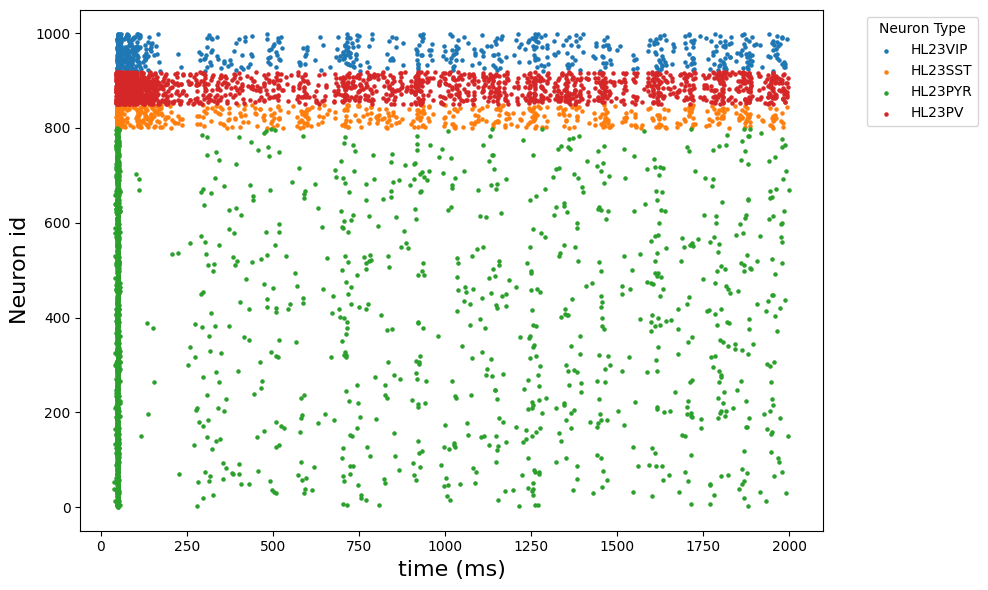

In [12]:
unique_types = set(neuronType.values())

plt.figure(figsize=(10, 6))

for cell_type in unique_types:
    valid_ids = [nid for nid, ctype in neuronType.items() if ctype == cell_type]
    mask = np.isin(spkid, valid_ids)
    plt.scatter(spkt[mask], spkid[mask], label=cell_type, s=5)

plt.xlabel('time (ms)', fontsize = 16)
plt.ylabel('Neuron id', fontsize = 16)


plt.legend(title='Neuron Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ensures the legend isn't cut off when saving

plt.show()

In [15]:
data['V_soma'].keys()

dict_keys(['cell_0', 'cell_1', 'cell_800', 'cell_801', 'cell_850', 'cell_851', 'cell_920', 'cell_921', 'cell_3', '__dict__'])

Text(0, 0.5, 'V (mV)')

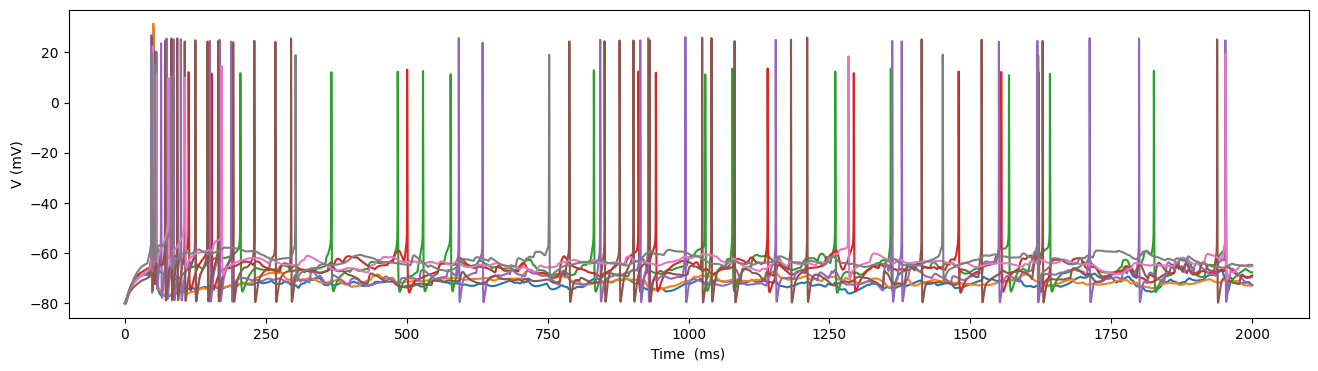

In [19]:
plt.figure(figsize=(16,4))
t = np.linspace(0.0, cfg.duration, len(data['V_soma']['cell_0']))
plt.plot(t, data['V_soma']['cell_0'])
plt.plot(t, data['V_soma']['cell_1'])
plt.plot(t, data['V_soma']['cell_800'])
plt.plot(t, data['V_soma']['cell_801'])
plt.plot(t, data['V_soma']['cell_850'])
plt.plot(t, data['V_soma']['cell_851'])
plt.plot(t, data['V_soma']['cell_920'])
plt.plot(t, data['V_soma']['cell_921'])
plt.xlabel('Time  (ms)')
plt.ylabel('V (mV)')
